# Stitch Classifier

Identifies stockinette knit stitch vs. Single Crochet stitch from images using transfer learning with ResNet-18 pretrained on ImageNet.

# 1. Imports

In [3]:
import os
import copy
import json
import datetime

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import DataLoader, Dataset

from PIL import Image

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split


# Mount Google drive

In [4]:
from google.colab import drive
import zipfile

drive.mount('/content/drive')

# ── NOTE FOR GRADER ───────────────────────────────────────────────────────────
# Upload dataset.zip to your Google Drive root (My Drive) then run this cell
# ─────────────────────────────────────────────────────────────────────────────
zip_path = '/content/drive/MyDrive/dataset.zip'

print("Extracting dataset...")
with zipfile.ZipFile(zip_path, 'r') as zf:
    for member in zf.namelist():
        if '.ipynb_checkpoints' in member or '.git' in member:
            continue
        zf.extract(member, '/content/')

print("Dataset ready")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extracting dataset...
Dataset ready


# 2. Load DataSet

Scans the Google Drive folders and builds a CSV file of all image paths and labels

In [5]:
# load the dataset
data_directory = '/content/dataset'

# two classes for classification
classes = ['stockinette', 'single_crochet']

data = []

# Go through each folder and assign labels
for label, category in enumerate(classes):
  folder_path = os.path.join(data_directory, category)
  for image_name in os.listdir(folder_path):

    # skip hidden folders and non-image files
    if image_name.startswith('.'):
      continue

    image_path = os.path.join(folder_path, image_name) # only gets image files

    # Store image and label
    data.append([image_path, label])

# Convert to DataFrame and save
data_file = pd.DataFrame(data, columns=['file_path', 'label'])
data_file.to_csv('data_file.csv', index=False)


# 3. Transforms and Augmentation

* Resize to 256x256 to ensure room to work
* CenterCrop to 24x24 removes backgroud object (hands, surfaces, needles)
* RandomHorizontalFlip and RandomRotation augment the small dataset
* Normalize uses ImageNet mean/std since we use the pretrained weights of ImageNet

In [6]:
data_transforms = transforms.Compose([
    transforms.Resize(256), # Resize images
    transforms.CenterCrop(224),    # Crop center
    transforms.RandomHorizontalFlip(), # Augementation
    transforms.RandomVerticalFlip(), # Added this: a 'V' upside down is still not crochet!
    transforms.RandomGrayscale(p=0.2),
    transforms.RandomRotation(15),     # Slight rotation
    transforms.ToTensor(),             # Convert to tensor

    # Normalize - ImageNet stats
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
print("Done")


Done


# 4. Custom Dataset Class



In [7]:
class CrochetDataset(Dataset):
  def __init__(self, csv_file, transform=None):
    self.data_frame = pd.read_csv(csv_file)
    self.transform = transform

  def __len__(self):
    return len(self.data_frame)

  def __getitem__(self, index):
    # Get image path and label
    img_path = self.data_frame.iloc[index, 0]
    label = int(self.data_frame.iloc[index, 1])

    # Load Image and conver to RGB
    image = Image.open(img_path).convert("RGB")

    # Apply transforms if provided
    if self.transform:
      image = self.transform(image)
    return image, label




# 5. Train / Validation / Test Split

splits the dataset into:
* 70% training: model learns from these
* 15% validation: monitors training
* 15% test: final evaluation

In [8]:
train_data, temp_data = train_test_split(data_file, test_size=0.3, random_state=42)
val_data, test_data   = train_test_split(temp_data,  test_size=0.5, random_state=42)

# Save splits to CSV files
train_data.to_csv('train.csv', index=False)
val_data.to_csv('validation.csv',     index=False)
test_data.to_csv('test.csv',   index=False)

# Create dataset objects
train_dataset = CrochetDataset('train.csv', transform=data_transforms)
val_dataset   = CrochetDataset('validation.csv', transform=data_transforms)
test_dataset  = CrochetDataset('test.csv', transform=data_transforms)

# Create loaders
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=8, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=8, shuffle=False)


# 6. ResNet-18 Transfer Learning

Uses ResNet-18 pretrained on ImageNet.

Why use transfer learning?
* The dataset collected only contain around 200 images. This is to small to train a CNN from scratch.

Why ResNet-18?
  
  * ResNet-18 already knows how to detect edges, textures, and patterns from ImageNet, which transfers well to stitch texture classification



Two-step approach:
1. Freeze backbone: only train the new classifier head

2. The frozen layers keep their ImageNet texture knowledge intact

In [9]:
# Load ResNet-18 with pre-trained ImageNet weights
model = models.resnet18(weights='IMAGENET1K_V1')

# Freeze backbone layers, to preserved ImageNet features
for param in model.parameters():
    param.requires_grad = False


num_ftrs = model.fc.in_features # 512 features from ResNet backbone
model.fc = nn.Linear(num_ftrs, 2) # replace the final layer for 2 classes

# Define loss function and optimizer
losses = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)




Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 128MB/s]


# 7. Training Loop
Trains for 10 epochs

After each epoch:
*   Prints train and validation loss and accuracy
*   If accuracy impoved, the model will be saved



In [10]:
EPOCHS = 10  # due to the small dataset
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

#
train_losses=[]
train_accuracies =[]
val_losses=[]
val_accuracies=[]

best_val_accuracy = 0.0
best_weights = copy.deepcopy(model.state_dict())

# Training Loop
for epoch in range(EPOCHS):
  model.train()

  total_loss = 0
  correct = 0
  total = 0

  for images, labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()   # clear old gradients
    outputs = model(images) # Forward Padd
    loss = losses(outputs, labels) # calculate loss
    loss.backward()   # backpropagate error
    optimizer.step()  # update weights

    total_loss += loss.item()
    correct += (outputs.argmax(1) == labels).sum().item()
    total += labels.size(0)

  # Training Metrics
  epoch_loss = total_loss / len(train_loader)
  epoch_accuracy = correct / total * 100
  train_losses.append(epoch_loss)
  train_accuracies.append(epoch_accuracy)

  # Validation
  model.eval()
  val_loss = 0
  val_correct = 0
  val_total = 0

  with torch.no_grad():
    for images, labels in val_loader:
      images = images.to(device)
      labels = labels.to(device)

      outputs = model(images)
      loss = losses(outputs, labels)

      val_loss += loss.item()
      val_correct += (outputs.argmax(1) == labels).sum().item()
      val_total += labels.size(0)

  epoch_val_loss = val_loss / len(val_loader)
  epoch_val_accuracy = val_correct / val_total * 100
  val_losses.append(epoch_val_loss)
  val_accuracies.append(epoch_val_accuracy)


  # Save the best model
  if epoch_val_accuracy > best_val_accuracy:
    best_val_accuracy = epoch_val_accuracy
    best_weights = copy.deepcopy(model.state_dict())
    torch.save(best_weights, 'best_model.pth')

    print(f"Best model soved: {epoch_val_accuracy:.2f}%")

  print(f"Epoch {epoch+1}/{EPOCHS}:")
  print(f"   Train Loss: {epoch_loss:.4f}, Train Accuracy: {epoch_accuracy:.2f}%")
  print(f"   Val Loss: {epoch_val_loss:.4f}, Val Accuracy: {epoch_val_accuracy:.2f}%")

# Load best model
print(f"Best validation accuracy:{best_val_accuracy:.2f}%")
model.load_state_dict(best_weights)




Best model soved: 77.42%
Epoch 1/10:
   Train Loss: 0.7223, Train Accuracy: 52.78%
   Val Loss: 0.4812, Val Accuracy: 77.42%
Best model soved: 80.65%
Epoch 2/10:
   Train Loss: 0.5123, Train Accuracy: 75.00%
   Val Loss: 0.3666, Val Accuracy: 80.65%
Epoch 3/10:
   Train Loss: 0.4324, Train Accuracy: 78.47%
   Val Loss: 0.3879, Val Accuracy: 80.65%
Best model soved: 83.87%
Epoch 4/10:
   Train Loss: 0.4100, Train Accuracy: 83.33%
   Val Loss: 0.3743, Val Accuracy: 83.87%
Best model soved: 90.32%
Epoch 5/10:
   Train Loss: 0.3639, Train Accuracy: 84.72%
   Val Loss: 0.2349, Val Accuracy: 90.32%
Best model soved: 93.55%
Epoch 6/10:
   Train Loss: 0.3518, Train Accuracy: 84.03%
   Val Loss: 0.1983, Val Accuracy: 93.55%
Epoch 7/10:
   Train Loss: 0.2533, Train Accuracy: 90.97%
   Val Loss: 0.2844, Val Accuracy: 90.32%
Epoch 8/10:
   Train Loss: 0.2706, Train Accuracy: 90.28%
   Val Loss: 0.2710, Val Accuracy: 87.10%
Epoch 9/10:
   Train Loss: 0.2711, Train Accuracy: 88.89%
   Val Loss: 0.32

<All keys matched successfully>

# 8. Training Results

Plots Training and Validation loss and accuracy across all epochs

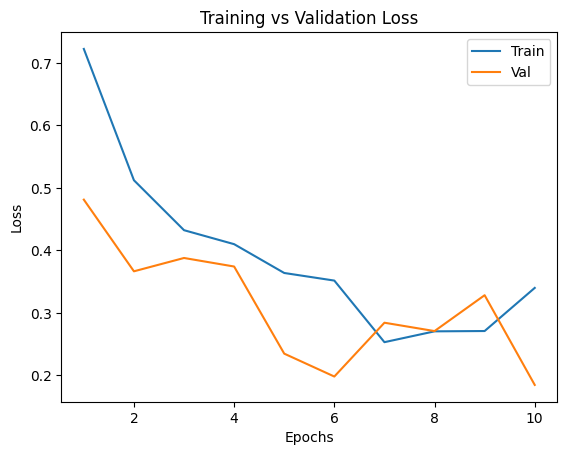

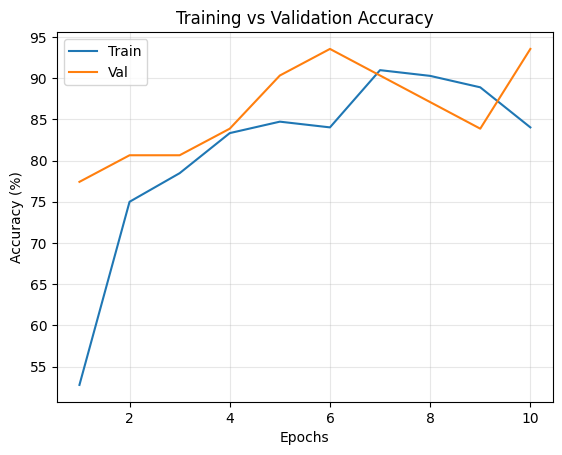

Saved: Plots


In [11]:
epochs_range = range(1, EPOCHS + 1)

# Loss graph
plt.figure()
plt.plot(epochs_range, train_losses, label="Train")
plt.plot(epochs_range, val_losses,   label="Val")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.savefig("loss_plot.png", dpi=300, bbox_inches='tight')
plt.show()

# Accuracy graph
plt.figure()
plt.plot(epochs_range, train_accuracies, label="Train")
plt.plot(epochs_range, val_accuracies,   label="Val")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("training_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved: Plots")



# 9. Test Evaluation
Runs the best saved model on the held-out test set.

Reports:
*   Precision
*   Recall
*   F1 score
*   Confusion matrix





Test Accuracy: 84.38%

                precision    recall  f1-score   support

   stockinette       0.92      0.73      0.81        15
single_crochet       0.80      0.94      0.86        17

      accuracy                           0.84        32
     macro avg       0.86      0.84      0.84        32
  weighted avg       0.85      0.84      0.84        32



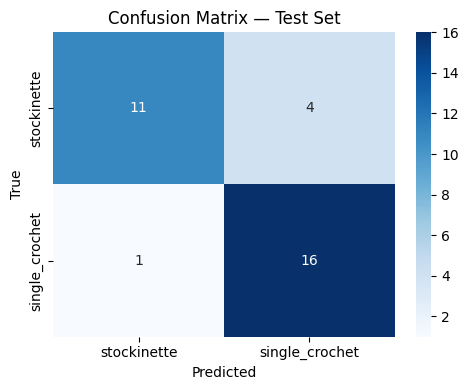

Saved: confusion_matrix.png


In [12]:
# ── Test set evaluation ────────────────────────────────────────────────────────
model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs   = model(images.to(device))
        predicted = outputs.argmax(1).cpu().numpy()
        all_preds.extend(predicted)
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
test_acc   = (all_preds == all_labels).mean() * 100

# Classification Report
print(f"Test Accuracy: {test_acc:.2f}%\n")
print(classification_report(all_labels, all_preds, target_names=classes))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved: confusion_matrix.png")

# 10. Stitch Database
Builds a Structured database of stitch information from the dataset.

In [13]:
# ── Build database from your actual dataset ────────────────────────────────────
stitch_database = {}

for i, category in enumerate(classes):
    folder = os.path.join(data_directory, category)

    # Get all images for this class
    images = [
        f for f in os.listdir(folder)
        if f.lower().endswith(('.jpg', '.jpeg', '.png', '.heic'))
        and not f.startswith('.')
    ]

    stitch_database[category] = {
        "id":           i,
        "name":         category,
        "total_images": len(images),
        "sample_images": images[:5],   # first 5 filenames as examples
    }

# Save to JSON
with open("stitch_database.json", "w") as f:
    json.dump(stitch_database, f, indent=2)

print("Database created")



Database created


# 11. Predict New Image
  Upload any fabric photo and the model will identify the stitch type and show the confidence scores.

In [ ]:
from google.colab import files

# ── Load best model ────────────────────────────────────────────────────────────
model.load_state_dict(torch.load('best_model.pth', map_location=device))
model.eval()

# ── Same transforms as training (no augmentation) ─────────────────────────────
predict_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


# Upload and predict
print("Upload a fabric image...")
uploaded = files.upload()

for filename in uploaded.keys():

    # Open image
    image = Image.open(filename).convert("RGB")

    # Show the image
    plt.figure(figsize=(4, 4))
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Uploaded: {filename}")
    plt.show()

    # Preprocess
    tensor = predict_transform(image).unsqueeze(0).to(device)

    # Predict
    with torch.no_grad():
        outputs = model(tensor)
        probs   = torch.softmax(outputs, dim=1)[0]
        pred_idx = probs.argmax().item()

    predicted_class = classes[pred_idx]
    confidence      = probs[pred_idx].item() * 100

    # ── Results ────────────────────────────────────────────────────────────────
    print(f"\n{'='*35}")
    print(f"  Predicted:  {predicted_class}")
    print(f"  Confidence: {confidence:.1f}%")
    print(f"{'='*35}")
    print(f"  stockinette:   {probs[0].item()*100:.1f}%")
    print(f"  single_crochet: {probs[1].item()*100:.1f}%")

Upload a fabric image...
